# RetailPulse: AI-Powered Sales & Retail Analytics Platform
## Day 10 — Inventory Optimization (ABC Analysis + EOQ)

**Module:** Inventory Optimization (Phase 3/4)

**Requirement (F-05):** Recommend reorder quantities using forecasted demand; reduce overstock/understock by 25–40%.

Uses `data/processed/sales_cleaned.csv` (historical per-product demand) and `data/processed/hybrid_forecast_30d.csv` (Day 8's forecast) plus `products_master.csv` (unit cost, lead time). This notebook:
1. Runs ABC analysis — classifies SKUs by revenue contribution (Pareto)
2. Allocates the Day 8 aggregate demand forecast down to per-product level
3. Computes EOQ (Economic Order Quantity) per product
4. Computes reorder points with safety stock, using lead time and demand variability
5. Produces the final reorder-quantity recommendation table for the dashboard

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"
REPORTS_DIR = "../reports"

sales = pd.read_csv(f"{PROCESSED_DIR}/sales_cleaned.csv", parse_dates=["InvoiceDate"])
products = pd.read_csv(f"{RAW_DIR}/products_master.csv")
hybrid_forecast = pd.read_csv(f"{PROCESSED_DIR}/hybrid_forecast_30d.csv", parse_dates=["ds"])

print(f"Transactions: {len(sales):,} | Products: {len(products)} | Forecast horizon: {len(hybrid_forecast)} days")

Transactions: 420,663 | Products: 120 | Forecast horizon: 30 days


## 1. ABC Analysis

Classic Pareto classification by revenue contribution:
- **A** — top SKUs contributing the first 80% of cumulative revenue (tightest control)
- **B** — next 15% of cumulative revenue (moderate control)
- **C** — remaining 5% (loose control, order in bulk infrequently)

In [2]:
product_revenue = (sales.groupby("StockCode")
                    .agg(TotalRevenue=("TotalPrice", "sum"),
                         TotalUnitsSold=("Quantity", "sum"),
                         NumOrders=("InvoiceNo", "nunique"))
                    .reset_index()
                    .sort_values("TotalRevenue", ascending=False))

product_revenue["CumRevenue"] = product_revenue["TotalRevenue"].cumsum()
product_revenue["CumRevenuePct"] = product_revenue["CumRevenue"] / product_revenue["TotalRevenue"].sum()

def abc_class(cum_pct):
    if cum_pct <= 0.80:
        return "A"
    elif cum_pct <= 0.95:
        return "B"
    return "C"

product_revenue["ABC_Category"] = product_revenue["CumRevenuePct"].apply(abc_class)

print(product_revenue["ABC_Category"].value_counts())
product_revenue["ABC_Category"].value_counts(normalize=True).round(3) * 100

ABC_Category
A    67
B    27
C    26
Name: count, dtype: int64


ABC_Category
A    55.8
B    22.5
C    21.7
Name: proportion, dtype: float64

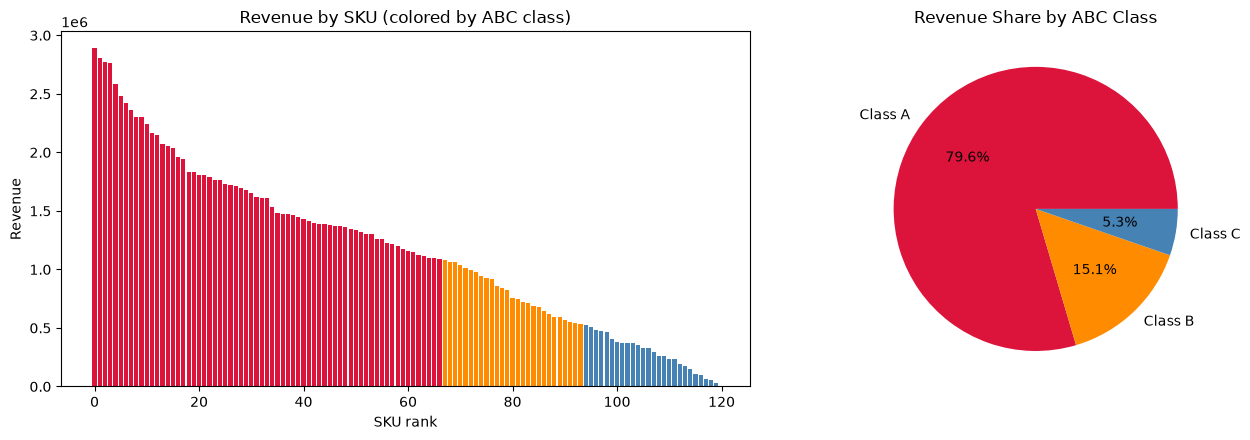

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

colors = product_revenue["ABC_Category"].map({"A": "crimson", "B": "darkorange", "C": "steelblue"})
axes[0].bar(range(len(product_revenue)), product_revenue["TotalRevenue"], color=colors)
axes[0].set_title("Revenue by SKU (colored by ABC class)")
axes[0].set_xlabel("SKU rank"); axes[0].set_ylabel("Revenue")

abc_summary = product_revenue.groupby("ABC_Category")["TotalRevenue"].sum()
axes[1].pie(abc_summary, labels=[f"Class {c}" for c in abc_summary.index],
            autopct="%1.1f%%", colors=["crimson", "darkorange", "steelblue"])
axes[1].set_title("Revenue Share by ABC Class")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day10_abc_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Allocate Forecasted Demand to Products

The Day 8 hybrid forecast projects total daily revenue, not per-SKU demand. Allocate the forecasted 30-day revenue total across products in proportion to each SKU's historical revenue share — a standard approach when a top-down forecast needs to inform bottom-up reorder decisions.

In [4]:
forecast_total_revenue_30d = hybrid_forecast["yhat_hybrid"].sum()
product_revenue["RevenueShare"] = product_revenue["TotalRevenue"] / product_revenue["TotalRevenue"].sum()
product_revenue["Forecasted30dRevenue"] = product_revenue["RevenueShare"] * forecast_total_revenue_30d

product_master = products.set_index("StockCode")
product_revenue["UnitPrice"] = product_revenue["StockCode"].map(product_master["UnitPrice"])
product_revenue["UnitCost"] = product_revenue["StockCode"].map(product_master["UnitCost"])
product_revenue["LeadTimeDays"] = product_revenue["StockCode"].map(product_master["LeadTimeDays"])

product_revenue["Forecasted30dUnits"] = product_revenue["Forecasted30dRevenue"] / product_revenue["UnitPrice"]
product_revenue["ForecastedAnnualDemand"] = product_revenue["Forecasted30dUnits"] * (365 / 30)

print(f"Total forecasted 30-day revenue: {forecast_total_revenue_30d:,.0f}")
product_revenue[["StockCode", "ABC_Category", "Forecasted30dUnits", "ForecastedAnnualDemand"]].head()

Total forecasted 30-day revenue: 8,821,078


,StockCode,ABC_Category,Forecasted30dUnits,ForecastedAnnualDemand
109,10109,A,1650.557044,20081.777366
53,10053,A,1654.591118,20130.858604
89,10089,A,1665.824464,20267.530975
40,10040,A,1580.302087,19227.008726
95,10095,A,1641.930331,19976.819025


## 3. Economic Order Quantity (EOQ)

$$EOQ = \sqrt{\dfrac{2DS}{H}}$$

- **D** — forecasted annual demand (units)
- **S** — fixed ordering cost per order (assumed flat per the project's cost model)
- **H** — annual holding cost per unit (modeled as a percentage of unit cost — standard inventory-theory assumption for holding/carrying cost)

In [5]:
ORDERING_COST_PER_ORDER = 25.0     # fixed cost to place one purchase order
HOLDING_COST_RATE = 0.20           # 20% of unit cost per year (typical retail assumption)

product_revenue["HoldingCostPerUnit"] = product_revenue["UnitCost"] * HOLDING_COST_RATE
product_revenue["EOQ"] = np.sqrt(
    (2 * product_revenue["ForecastedAnnualDemand"] * ORDERING_COST_PER_ORDER)
    / product_revenue["HoldingCostPerUnit"].clip(lower=0.01)
).round(0)

product_revenue[["StockCode", "ABC_Category", "ForecastedAnnualDemand", "EOQ"]].head(10)

,StockCode,ABC_Category,ForecastedAnnualDemand,EOQ
109,10109,A,20081.777366,361.0
53,10053,A,20130.858604,367.0
89,10089,A,20267.530975,365.0
40,10040,A,19227.008726,352.0
95,10095,A,19976.819025,358.0
59,10059,A,19689.882556,388.0
21,10021,A,20319.632597,370.0
117,10117,A,19987.390369,391.0
116,10116,A,19581.148736,399.0
51,10051,A,18871.358523,360.0


## 4. Reorder Point with Safety Stock

$$ROP = (\text{daily demand} \times \text{lead time}) + \text{safety stock}$$

Safety stock accounts for demand variability during lead time, using a service-level z-score (95% service level for A-items, lower for B/C since stockout cost tolerance differs by revenue importance).

In [6]:
SERVICE_LEVEL_BY_CLASS = {"A": 0.98, "B": 0.95, "C": 0.90}

daily_demand_std = (sales.groupby(["StockCode", sales["InvoiceDate"].dt.date])["Quantity"]
                     .sum().groupby("StockCode").std().fillna(0))
product_revenue["DailyDemandStd"] = product_revenue["StockCode"].map(daily_demand_std).fillna(0)
product_revenue["DailyDemandMean"] = product_revenue["Forecasted30dUnits"] / 30

product_revenue["ServiceLevel"] = product_revenue["ABC_Category"].map(SERVICE_LEVEL_BY_CLASS)
product_revenue["ZScore"] = product_revenue["ServiceLevel"].apply(norm.ppf)

product_revenue["SafetyStock"] = (
    product_revenue["ZScore"] * product_revenue["DailyDemandStd"]
    * np.sqrt(product_revenue["LeadTimeDays"])
).clip(lower=0).round(0)

product_revenue["ReorderPoint"] = (
    product_revenue["DailyDemandMean"] * product_revenue["LeadTimeDays"] + product_revenue["SafetyStock"]
).round(0)

product_revenue[["StockCode", "ABC_Category", "ServiceLevel", "SafetyStock", "ReorderPoint"]].head(10)

,StockCode,ABC_Category,ServiceLevel,SafetyStock,ReorderPoint
109,10109,A,0.98,128.0,458.0
53,10053,A,0.98,111.0,387.0
89,10089,A,0.98,97.0,319.0
40,10040,A,0.98,242.0,1664.0
95,10095,A,0.98,248.0,1726.0
59,10059,A,0.98,131.0,509.0
21,10021,A,0.98,202.0,1148.0
117,10117,A,0.98,128.0,511.0
116,10116,A,0.98,269.0,1771.0
51,10051,A,0.98,122.0,432.0


## 5. Visualize Recommendations by ABC Class

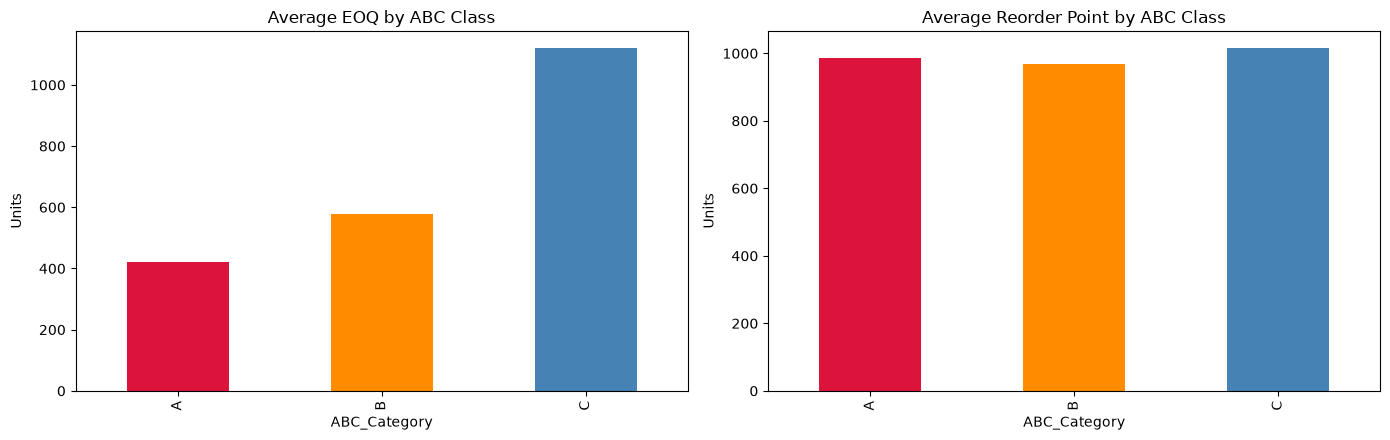

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

eoq_by_class = product_revenue.groupby("ABC_Category")["EOQ"].mean()
eoq_by_class.plot(kind="bar", ax=axes[0], color=["crimson", "darkorange", "steelblue"])
axes[0].set_title("Average EOQ by ABC Class")
axes[0].set_ylabel("Units")

rop_by_class = product_revenue.groupby("ABC_Category")["ReorderPoint"].mean()
rop_by_class.plot(kind="bar", ax=axes[1], color=["crimson", "darkorange", "steelblue"])
axes[1].set_title("Average Reorder Point by ABC Class")
axes[1].set_ylabel("Units")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day10_eoq_rop_by_class.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Overstock / Understock Risk vs Current Inventory

Compare the recommended reorder point against the most recent inventory snapshot to flag SKUs currently at risk of stockout (below ROP) or overstock (well above EOQ + ROP).

In [8]:
inventory = pd.read_csv(f"{RAW_DIR}/inventory_snapshots.csv", parse_dates=["SnapshotDate"])
latest_snapshot = inventory[inventory["SnapshotDate"] == inventory["SnapshotDate"].max()]
current_stock = latest_snapshot.set_index("StockCode")["UnitsOnHand"]

product_revenue["CurrentStock"] = product_revenue["StockCode"].map(current_stock).fillna(0)

def risk_flag(row):
    if row["CurrentStock"] < row["ReorderPoint"]:
        return "Understock Risk"
    elif row["CurrentStock"] > (row["ReorderPoint"] + row["EOQ"] * 1.5):
        return "Overstock Risk"
    return "Healthy"

product_revenue["StockRisk"] = product_revenue.apply(risk_flag, axis=1)
product_revenue["RecommendedOrderQty"] = np.where(
    product_revenue["StockRisk"] == "Understock Risk",
    (product_revenue["ReorderPoint"] + product_revenue["EOQ"] - product_revenue["CurrentStock"]).clip(lower=0),
    0,
)

print(product_revenue["StockRisk"].value_counts())
product_revenue[["StockCode", "ABC_Category", "CurrentStock", "ReorderPoint", "EOQ", "StockRisk", "RecommendedOrderQty"]].head(10)

StockRisk
Healthy            56
Understock Risk    42
Overstock Risk     22
Name: count, dtype: int64


,StockCode,ABC_Category,CurrentStock,ReorderPoint,EOQ,StockRisk,RecommendedOrderQty
109,10109,A,1944,458.0,361.0,Overstock Risk,0.0
53,10053,A,1229,387.0,367.0,Overstock Risk,0.0
89,10089,A,966,319.0,365.0,Overstock Risk,0.0
40,10040,A,1192,1664.0,352.0,Understock Risk,824.0
95,10095,A,952,1726.0,358.0,Understock Risk,1132.0
59,10059,A,1671,509.0,388.0,Overstock Risk,0.0
21,10021,A,935,1148.0,370.0,Understock Risk,583.0
117,10117,A,842,511.0,391.0,Healthy,0.0
116,10116,A,1744,1771.0,399.0,Understock Risk,426.0
51,10051,A,1109,432.0,360.0,Overstock Risk,0.0


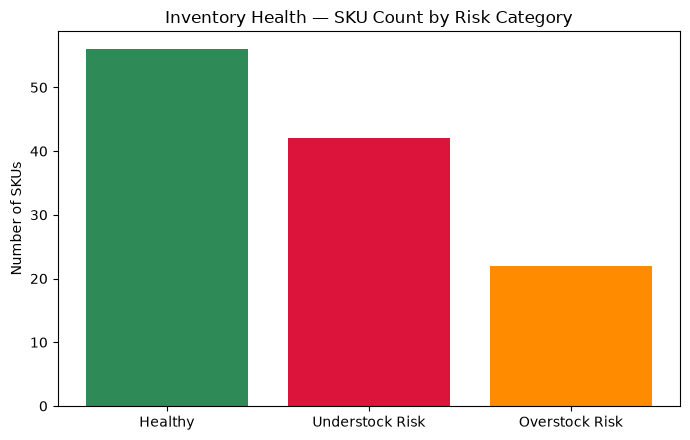

In [9]:
plt.figure(figsize=(7, 4.5))
risk_counts = product_revenue["StockRisk"].value_counts()
colors_map = {"Healthy": "seagreen", "Understock Risk": "crimson", "Overstock Risk": "darkorange"}
plt.bar(risk_counts.index, risk_counts.values, color=[colors_map[i] for i in risk_counts.index])
plt.title("Inventory Health — SKU Count by Risk Category")
plt.ylabel("Number of SKUs")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day10_stock_risk.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Save Final Recommendations

In [10]:
output_cols = ["StockCode", "ABC_Category", "TotalRevenue", "ForecastedAnnualDemand",
               "EOQ", "ReorderPoint", "SafetyStock", "CurrentStock", "StockRisk", "RecommendedOrderQty"]
inventory_recommendations = product_revenue[output_cols].round(1)
inventory_recommendations.to_csv(f"{PROCESSED_DIR}/inventory_recommendations.csv", index=False)

print(f"Saved inventory_recommendations.csv ({len(inventory_recommendations)} SKUs)")
print(f"SKUs needing reorder now: {(inventory_recommendations['RecommendedOrderQty'] > 0).sum()}")
inventory_recommendations.sort_values('RecommendedOrderQty', ascending=False).head(10)

Saved inventory_recommendations.csv (120 SKUs)
SKUs needing reorder now: 42


,StockCode,ABC_Category,TotalRevenue,ForecastedAnnualDemand,EOQ,ReorderPoint,SafetyStock,CurrentStock,StockRisk,RecommendedOrderQty
60,10060,C,54256.3,19887.7,2166.0,1049.0,123.0,880,Understock Risk,2335.0
119,10119,C,257838.0,19866.6,1000.0,1288.0,145.0,691,Understock Risk,1597.0
39,10039,C,371123.1,20117.3,970.0,1418.0,150.0,854,Understock Risk,1534.0
64,10064,A,1100896.9,19363.7,407.0,1748.0,263.0,667,Understock Risk,1488.0
7,10007,C,147623.0,19352.4,1058.0,1367.0,148.0,980,Understock Risk,1445.0
66,10066,C,328539.1,19472.4,764.0,1544.0,157.0,868,Understock Risk,1440.0
55,10055,B,1080623.5,20058.4,407.0,1800.0,206.0,828,Understock Risk,1379.0
113,10113,C,481815.6,19570.6,794.0,1544.0,150.0,996,Understock Risk,1342.0
90,10090,B,641998.0,19786.5,689.0,1727.0,209.0,1092,Understock Risk,1324.0
9,10009,C,406039.4,19793.3,742.0,1340.0,147.0,809,Understock Risk,1273.0


## 8. Day 10 Checkpoint Summary

**Outputs saved:**
- `data/processed/inventory_recommendations.csv` — ABC class, EOQ, reorder point, safety stock, current stock, risk flag, and recommended order quantity per SKU
- `reports/day10_abc_analysis.png`, `day10_eoq_rop_by_class.png`, `day10_stock_risk.png`

**Method summary:**
- ABC (Pareto) classification by historical revenue contribution
- Day 8's hybrid forecast allocated down to SKU level by historical revenue share
- EOQ computed from forecasted annual demand, ordering cost, and holding cost
- Reorder point includes safety stock scaled by ABC-tiered service level (A=98%, B=95%, C=90%)
- Current inventory snapshot compared against ROP/EOQ to flag under/overstock risk

**Next module:** `11_feature_importance_tuning` — Optuna hyperparameter tuning + feature importance analysis across the forecasting/churn models.